In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install --upgrade pip
!pip install update-checker==0.18.0
!pip install metric-visualizer==0.9.6
!pip install pyabsa -U
!pip install "transformers<=4.29.0"

  Using cached transformers-4.29.0-py3-none-any.whl.metadata (111 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.29.0-py3-none-any.whl (7.1 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
error: failed-wheel-build-for-install

× Failed to build installable wheels for some pyproject.toml based projects
╰─> tokenizers


In [5]:
from transformers import PretrainedConfig

# Monkeypatch transformers config to prevent the 'is_decoder' attribute error in older PyABSA libraries
if not hasattr(PretrainedConfig, 'is_decoder'):
    PretrainedConfig.is_decoder = False

from pyabsa import AspectTermExtraction as ATEPC

# 1. Initialize the Aspect Extractor model
aspect_extractor = ATEPC.AspectExtractor('english', auto_device=True)

# 2. Define the target automotive review
reviews = [
    "The battery range is excellent, but the charging time is too long."
]

# 3. Execute the NLP pipeline
results = aspect_extractor.predict(text=reviews, print_result=True)

# 4. Format the final output table
print(f"{'Aspect':<20} | {'Sentiment'}")
print("-" * 35)
for result in results:
    for aspect, sentiment in zip(result['aspect'], result['sentiment']):
        print(f"{aspect:<20} | {sentiment}")

[2026-09-29 04:58:06] (2.4.2) ********** Available ATEPC model checkpoints for Version:2.4.2 (this version) **********
[2026-09-29 04:58:06] (2.4.2) ********** Available ATEPC model checkpoints for Version:2.4.2 (this version) **********
[2026-09-29 04:58:06] (2.4.2) Downloading checkpoint:english 
[2026-09-29 04:58:06] (2.4.2) Notice: The pretrained model are used for testing, it is recommended to train the model on your own custom datasets
[2026-09-29 04:58:06] (2.4.2) Checkpoint already downloaded, skip
[2026-09-29 04:58:06] (2.4.2) Load aspect extractor from checkpoints/ATEPC_ENGLISH_CHECKPOINT/fast_lcf_atepc_English_cdw_apcacc_82.36_apcf1_81.89_atef1_75.43
[2026-09-29 04:58:06] (2.4.2) config: checkpoints/ATEPC_ENGLISH_CHECKPOINT/fast_lcf_atepc_English_cdw_apcacc_82.36_apcf1_81.89_atef1_75.43/fast_lcf_atepc.config
[2026-09-29 04:58:06] (2.4.2) state_dict: checkpoints/ATEPC_ENGLISH_CHECKPOINT/fast_lcf_atepc_English_cdw_apcacc_82.36_apcf1_81.89_atef1_75.43/fast_lcf_atepc.state_dict


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.13/dist-package

[2026-09-29 04:58:15] (2.4.2) The results of aspect term extraction have been saved in /content/Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
[2026-09-29 04:58:15] (2.4.2) Example 0: The <battery range:Positive Confidence:0.8212> is excellent , but the <charging time:Negative Confidence:0.6033> is too long .
Aspect               | Sentiment
-----------------------------------
battery range        | Positive
charging time        | Negative


In [6]:
import json
from transformers import PretrainedConfig

# Monkeypatch transformers config to prevent the 'is_decoder' attribute error in older PyABSA libraries
if not hasattr(PretrainedConfig, 'is_decoder'):
    PretrainedConfig.is_decoder = False

from pyabsa import AspectTermExtraction as ATEPC

# 1. Initialize the Aspect Extractor model
spect_extractor = ATEPC.AspectExtractor('english', auto_device=True)

# 2. Define the target automotive review
reviews = [
    "The battery range is excellent, but the charging time is too long."
]

# 3. Run the prediction
results = aspect_extractor.predict(text=reviews, print_result=False)

# 4. Print the full dictionary structure of the results
try:
    print(json.dumps(results, indent=2, default=str))
except Exception as e:
    # Fallback to direct print if there are non-serializable objects
    print(results)

[2026-09-29 04:58:39] (2.4.2) ********** Available ATEPC model checkpoints for Version:2.4.2 (this version) **********
[2026-09-29 04:58:39] (2.4.2) ********** Available ATEPC model checkpoints for Version:2.4.2 (this version) **********
[2026-09-29 04:58:39] (2.4.2) Downloading checkpoint:english 
[2026-09-29 04:58:39] (2.4.2) Notice: The pretrained model are used for testing, it is recommended to train the model on your own custom datasets
[2026-09-29 04:58:39] (2.4.2) Checkpoint already downloaded, skip
[2026-09-29 04:58:39] (2.4.2) Load aspect extractor from checkpoints/ATEPC_ENGLISH_CHECKPOINT/fast_lcf_atepc_English_cdw_apcacc_82.36_apcf1_81.89_atef1_75.43
[2026-09-29 04:58:39] (2.4.2) config: checkpoints/ATEPC_ENGLISH_CHECKPOINT/fast_lcf_atepc_English_cdw_apcacc_82.36_apcf1_81.89_atef1_75.43/fast_lcf_atepc.config
[2026-09-29 04:58:39] (2.4.2) state_dict: checkpoints/ATEPC_ENGLISH_CHECKPOINT/fast_lcf_atepc_English_cdw_apcacc_82.36_apcf1_81.89_atef1_75.43/fast_lcf_atepc.state_dict


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[2026-09-29 04:58:43] (2.4.2) The results of aspect term extraction have been saved in /content/Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
[
  {
    "sentence": "The battery range is excellent , but the charging time is too long .",
    "IOB": [
      "O",
      "B-ASP",
      "I-ASP",
      "O",
      "O",
      "O",
      "O",
      "O",
      "B-ASP",
      "I-ASP",
      "O",
      "O",
      "O",
      "O"
    ],
    "tokens": [
      "The",
      "battery",
      "range",
      "is",
      "excellent",
      ",",
      "but",
      "the",
      "charging",
      "time",
      "is",
      "too",
      "long",
      "."
    ],
    "aspect": [
      "battery range",
      "charging time"
    ],
    "position": [
      [
        1,
        2
      ],
      [
        8,
        9
      ]
    ],
    "sentiment": [
      "Positive",
      "Negative"
    ],
    "probs": [
      [
        0.13424590229988098,
        0.04450426995754242,
        0.821249

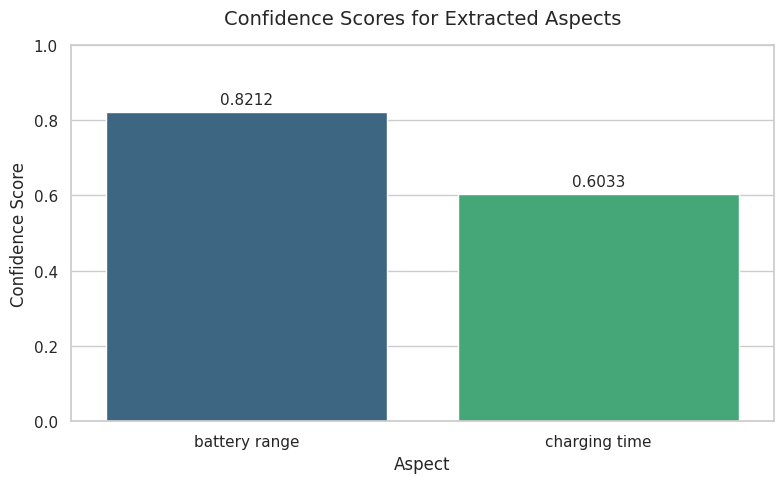

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract aspects and their confidence scores
aspects = []
confidences = []

for result in results:
    for aspect, confidence in zip(result['aspect'], result['confidence']):
        aspects.append(aspect)
        confidences.append(confidence)

# Create the bar chart
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=aspects, y=confidences, palette="viridis", hue=aspects, legend=False)

# Customize the chart
plt.title("Confidence Scores for Extracted Aspects", fontsize=14, pad=15)
plt.xlabel("Aspect", fontsize=12)
plt.ylabel("Confidence Score", fontsize=12)
plt.ylim(0, 1.0)

# Display values on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11)

plt.tight_layout()
plt.show()

In [8]:
# Define a new, expanded list of reviews to test the model
new_reviews = [
    "The engine performance is incredibly smooth, but the fuel efficiency is disappointing.",
    "I absolutely love the spacious interior and the premium sound system of this car.",
    "The touchscreen display is unresponsive and lags constantly, although the navigation system is quite accurate.",
    "Despite the noisy cabin on highway speeds, the ride comfort and suspension are top-notch."
]

# Run prediction on the new dataset
new_results = aspect_extractor.predict(text=new_reviews, print_result=True)

# Format the results into a clean output table
print("\n" + "="*60)
print(f"{'Aspect Term':<25} | {'Sentiment':<12} | {'Confidence'}")
print("="*60)
for res in new_results:
    for aspect, sentiment, conf in zip(res['aspect'], res['sentiment'], res['confidence']):
        print(f"{aspect:<25} | {sentiment:<12} | {conf:.4f}")
print("="*60)

[2026-09-29 05:06:27] (2.4.2) The results of aspect term extraction have been saved in /content/Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
[2026-09-29 05:06:27] (2.4.2) Example 0: The <engine performance:Positive Confidence:0.914> is incredibly smooth , but the <fuel efficiency:Negative Confidence:0.6332> is disappointing .
[2026-09-29 05:06:27] (2.4.2) Example 1: I absolutely love the spacious <interior:Positive Confidence:0.9995> and the premium <sound system:Positive Confidence:0.9996> of this car .
[2026-09-29 05:06:27] (2.4.2) Example 2: The <touchscreen display:Negative Confidence:0.9993> is unresponsive and lags constantly , although the <navigation system:Positive Confidence:0.9995> is quite accurate .
[2026-09-29 05:06:27] (2.4.2) Example 3: Despite the noisy <cabin:Negative Confidence:0.9986> on highway speeds , the <ride comfort:Positive Confidence:0.9995> and <suspension:Positive Confidence:0.9995> are top - notch .

Aspect Term           

In [9]:
import pandas as pd
import os

# 1. Create a dummy CSV file to demonstrate loading batch reviews
csv_path = 'sample_reviews.csv'

mock_data = {
    'review_id': [1, 2, 3],
    'review_text': [
        "The steering wheel is very responsive, but the braking system feels slightly soft.",
        "Exceptional mileage and high-quality materials on the dashboard.",
        "The air conditioning cools quickly, though the back seats are tight."
    ]
}
pd.DataFrame(mock_data).to_csv(csv_path, index=False)
print(f"Created sample CSV at: {csv_path}\n")

# 2. Load the CSV using Pandas
df = pd.read_csv(csv_path)

# 3. Extract the list of review texts
batch_reviews = df['review_text'].tolist()

# 4. Predict using the aspect extractor
batch_results = aspect_extractor.predict(text=batch_reviews, print_result=False)

# 5. Format and display the results cleanly
print("=" * 70)
print(f"{'Review ID':<10} | {'Aspect Term':<25} | {'Sentiment':<12} | {'Confidence'}")
print("=" * 70)

for idx, res in enumerate(batch_results):
    row_id = df.iloc[idx]['review_id']
    if not res['aspect']:
        print(f"{row_id:<10} | {'No Aspects Found':<25} | {'-':<12} | {'-'}")
    else:
        for aspect, sentiment, conf in zip(res['aspect'], res['sentiment'], res['confidence']):
            print(f"{row_id:<10} | {aspect:<25} | {sentiment:<12} | {conf:.4f}")

print("=" * 70)

Created sample CSV at: sample_reviews.csv



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[2026-09-29 05:07:51] (2.4.2) The results of aspect term extraction have been saved in /content/Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
Review ID  | Aspect Term               | Sentiment    | Confidence
1          | steering wheel            | Positive     | 0.9956
1          | braking system            | Negative     | 0.9974
2          | mileage                   | Positive     | 0.9928
2          | materials                 | Positive     | 0.9956
2          | dashboard                 | Positive     | 0.9957
3          | air conditioning          | Positive     | 0.9993
3          | back seats                | Negative     | 0.9979


In [11]:
# 1. Structure the results into a flat list of records
processed_records = []

for idx, res in enumerate(batch_results):
    row_id = df.iloc[idx]['review_id']
    original_review = df.iloc[idx]['review_text']

    if not res['aspect']:
        processed_records.append({
            'review_id': row_id,
            'review_text': original_review,
            'aspect_term': 'No Aspects Found',
            'sentiment': None,
            'confidence': None
        })
    else:
        for aspect, sentiment, conf in zip(res['aspect'], res['sentiment'], res['confidence']):
            processed_records.append({
                'review_id': row_id,
                'review_text': original_review,
                'aspect_term': aspect,
                'sentiment': sentiment,
                'confidence': round(conf, 4)
            })

# 2. Convert to a pandas DataFrame
output_df = pd.DataFrame(processed_records)

# 3. Save the results to a new CSV file
output_csv_path = 'batch_extracted_aspects.csv'
output_df.to_csv(output_csv_path, index=False)

print(f"Successfully saved processed aspects to: {output_csv_path}")

# 4. Display the structured DataFrame
display(output_df)

Successfully saved processed aspects to: batch_extracted_aspects.csv


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,review_id,review_text,aspect_term,sentiment,confidence
0,1,"The steering wheel is very responsive, but the...",steering wheel,Positive,0.9956
1,1,"The steering wheel is very responsive, but the...",braking system,Negative,0.9974
2,2,Exceptional mileage and high-quality materials...,mileage,Positive,0.9928
3,2,Exceptional mileage and high-quality materials...,materials,Positive,0.9956
4,2,Exceptional mileage and high-quality materials...,dashboard,Positive,0.9957
5,3,"The air conditioning cools quickly, though the...",air conditioning,Positive,0.9993
6,3,"The air conditioning cools quickly, though the...",back seats,Negative,0.9979
